# Hindi CPT evaluation — base vs. continued-pretrained

Compares `Qwen3.5-9B` (**base**) against `qwen3p5-9b-hi-cpt` (**cpt**) across **four evaluation
categories**, loading the per-checkpoint result JSON and rendering comparison tables + plots
with Δ = CPT − base.

1. **General English** (retention) — WikiText-103 PPL/BPB + MMLU, BoolQ, GSM8K, HumanEval. Δ≈0 desired.
2. **Hindi language modeling** (adaptation) — Samanantar + in-domain proverbs, PPL/BPB (lower is better).
3. **Hindi idiom understanding** — MABL (figurative inference) + IdiomCE (idiomatic translation).
4. **Hindi general cultural competence** — MILU (cultural knowledge) + Global PIQA (cultural commonsense).

In [1]:
import json
from pathlib import Path
import pandas as pd

# Root where the eval jobs write results.
EVAL_ROOT = Path('/lustre-storage/fsx_it_0/users/jiaruiliu/culture_pretraining/eval/hi')
RUNS = ['base', 'cpt']

def load_json(p):
    p = Path(p)
    return json.loads(p.read_text()) if p.exists() else None

# Four evaluation categories (match the paper).
CAT_NAMES = {
    1: '(1) General English',
    2: '(2) Hindi language modeling',
    3: '(3) Hindi idiom understanding',
    4: '(4) Hindi general cultural competence',
}

# PPL/BPB corpora: (key, subdir, label, category, note)
PPL_CORPORA = [
    ('wikitext',      'ppl_wikitext',      'WikiText-103 (English)',     1, 'English LM retention (held-out test)'),
    ('hi_samanantar', 'ppl_hi_samanantar', 'Hindi Samanantar',           2, 'in-distribution probe (not in CPT corpus)'),
    ('hi_proverbs',   'ppl_hi_proverbs',   'Hindi proverbs (in-domain)', 2, 'CONTAMINATED (from training data)'),
]
print('EVAL_ROOT exists:', EVAL_ROOT.exists())
for r in RUNS:
    print(r, '->', (EVAL_ROOT / r).exists())

EVAL_ROOT exists: True
base -> True


cpt -> True


In [2]:
# ---- PPL + BPB rows: (1) English LM retention + (2) Hindi LM adaptation ---------
rows = []
for key, sub, label, cat, note in PPL_CORPORA:
    d = {r: load_json(EVAL_ROOT / r / sub / 'perplexity.json') for r in RUNS}
    for metric, field in [('PPL', 'ppl'), ('BPB', 'bits_per_byte')]:
        rec = {'category': cat, 'benchmark': label, 'metric': metric, 'note': note, 'better': 'lower'}
        for r in RUNS:
            rec[r] = d[r][field] if d[r] else None
        rows.append(rec)
lm = pd.DataFrame(rows)
lm['delta'] = pd.to_numeric(lm['cpt'], errors='coerce') - pd.to_numeric(lm['base'], errors='coerce')
lm

,category,benchmark,metric,note,better,base,cpt,delta
0,1,WikiText-103 (English),PPL,English LM retention (held-out test),lower,13.258000,13.784200,0.526200
1,1,WikiText-103 (English),BPB,English LM retention (held-out test),lower,0.860206,0.873159,0.012953
2,2,Hindi Samanantar,PPL,in-distribution probe (not in CPT corpus),lower,65.121900,3.432900,-61.689000
3,2,Hindi Samanantar,BPB,in-distribution probe (not in CPT corpus),lower,1.530465,0.451999,-1.078466
4,2,Hindi proverbs (in-domain),PPL,CONTAMINATED (from training data),lower,14.563900,2.476700,-12.087200
5,2,Hindi proverbs (in-domain),BPB,CONTAMINATED (from training data),lower,1.007077,0.340986,-0.666091


In [3]:
# ---- Accuracy / score benchmarks: categories 1, 3, 4 ----------------------------
summ     = {r: load_json(EVAL_ROOT / r / 'summary.json') for r in RUNS}
summ_en  = {r: load_json(EVAL_ROOT / r / 'en' / 'summary.json') for r in RUNS}
summ_gen = {r: load_json(EVAL_ROOT / r / 'en_gen' / 'summary.json') for r in RUNS}

# (task, category, label, metric key, better, source-dict)
SPEC = [
    ('mmlu',        1, 'MMLU (0-shot)',   'acc',      'higher', summ_en),
    ('boolq',       1, 'BoolQ (0-shot)',  'acc',      'higher', summ_en),
    ('mabl',        3, 'MABL',            'acc_norm', 'higher', summ),
    ('milu',        4, 'MILU (5-shot)',   'acc',      'higher', summ),
    ('global_piqa', 4, 'Global PIQA',     'acc_norm', 'higher', summ),
]
rows = []
for task, cat, label, mk, better, src in SPEC:
    rec = {'category': cat, 'benchmark': label, 'metric': mk, 'note': '', 'better': better}
    for r in RUNS:
        m = (src[r] or {}).get('tasks', {}).get(task) if src[r] else None
        rec[r] = m.get(mk) if m else None
    rows.append(rec)

# Category-1 generation benchmarks (report primary = EM / pass@1)
for task, label, metlabel in [('gsm8k', 'GSM8K (8-shot CoT)', 'EM'),
                              ('humaneval', 'HumanEval (0-shot)', 'pass@1')]:
    rec = {'category': 1, 'benchmark': label, 'metric': metlabel, 'note': '', 'better': 'higher'}
    for r in RUNS:
        m = (summ_gen[r] or {}).get('tasks', {}).get(task) if summ_gen[r] else None
        rec[r] = m.get('primary') if m else None
    rows.append(rec)

# Category-3 IdiomCE (1-5 idiom score; judged)
rec = {'category': 3, 'benchmark': 'IdiomCE', 'metric': 'idiom_score(1-5)', 'note': '', 'better': 'higher'}
for r in RUNS:
    m = (summ[r] or {}).get('tasks', {}).get('idiomce') if summ[r] else None
    if m and m.get('judged'):
        rec[r] = m.get('idiom_score_mean')
    elif m:
        rec[r] = None; rec['note'] = f"generated n={m.get('n')}, judge pending"
    else:
        rec[r] = None
rows.append(rec)

acc = pd.DataFrame(rows)
acc['delta'] = pd.to_numeric(acc['cpt'], errors='coerce') - pd.to_numeric(acc['base'], errors='coerce')
acc

,category,benchmark,metric,note,better,base,cpt,delta
0,1,MMLU (0-shot),acc,,higher,0.7852,0.7767,-0.0085
1,1,BoolQ (0-shot),acc,,higher,0.8850,0.8306,-0.0544
2,3,MABL,acc_norm,,higher,0.5310,0.5920,0.0610
3,4,MILU (5-shot),acc,,higher,0.5323,0.6081,0.0758
4,4,Global PIQA,acc_norm,,higher,0.6000,0.7200,0.1200
5,1,GSM8K (8-shot CoT),EM,,higher,0.8749,0.8590,-0.0159
6,1,HumanEval (0-shot),pass@1,,higher,0.7195,0.5915,-0.1280
7,3,IdiomCE,idiom_score(1-5),,higher,2.0575,2.4825,0.4250


In [4]:
# ---- Combined headline table, grouped by the four categories -------------------
allrows = pd.concat([lm[['category','benchmark','metric','base','cpt','delta','better','note']],
                     acc[['category','benchmark','metric','base','cpt','delta','better','note']]],
                    ignore_index=True)

FLAT_TOL = 0.01  # |Δ| below this (for higher-better metrics) counts as within-noise flat

def verdict(row):
    if pd.isna(row['delta']):
        return '—'
    if row['better'] != 'lower' and abs(row['delta']) < FLAT_TOL:
        return '≈ flat'
    good = (row['delta'] < 0) if row['better'] == 'lower' else (row['delta'] > 0)
    return '✅ improved' if good else '⚠️ regressed'

allrows['verdict'] = allrows.apply(verdict, axis=1)
allrows['cat_name'] = allrows['category'].map(CAT_NAMES)
allrows.sort_values(['category', 'benchmark']).reset_index(drop=True)[
    ['category', 'cat_name', 'benchmark', 'metric', 'base', 'cpt', 'delta', 'verdict', 'note']]

,category,cat_name,benchmark,metric,base,cpt,delta,verdict,note
0,1,(1) General English,BoolQ (0-shot),acc,0.885000,0.830600,-0.054400,⚠️ regressed,
1,1,(1) General English,GSM8K (8-shot CoT),EM,0.874900,0.859000,-0.015900,⚠️ regressed,
2,1,(1) General English,HumanEval (0-shot),pass@1,0.719500,0.591500,-0.128000,⚠️ regressed,
3,1,(1) General English,MMLU (0-shot),acc,0.785200,0.776700,-0.008500,≈ flat,
4,1,(1) General English,WikiText-103 (English),PPL,13.258000,13.784200,0.526200,⚠️ regressed,English LM retention (held-out test)
5,1,(1) General English,WikiText-103 (English),BPB,0.860206,0.873159,0.012953,⚠️ regressed,English LM retention (held-out test)
6,2,(2) Hindi language modeling,Hindi Samanantar,PPL,65.121900,3.432900,-61.689000,✅ improved,in-distribution probe (not in CPT corpus)
7,2,(2) Hindi language modeling,Hindi Samanantar,BPB,1.530465,0.451999,-1.078466,✅ improved,in-distribution probe (not in CPT corpus)
8,2,(2) Hindi language modeling,Hindi proverbs (in-domain),PPL,14.563900,2.476700,-12.087200,✅ improved,CONTAMINATED (from training data)
9,2,(2) Hindi language modeling,Hindi proverbs (in-domain),BPB,1.007077,0.340986,-0.666091,✅ improved,CONTAMINATED (from training data)


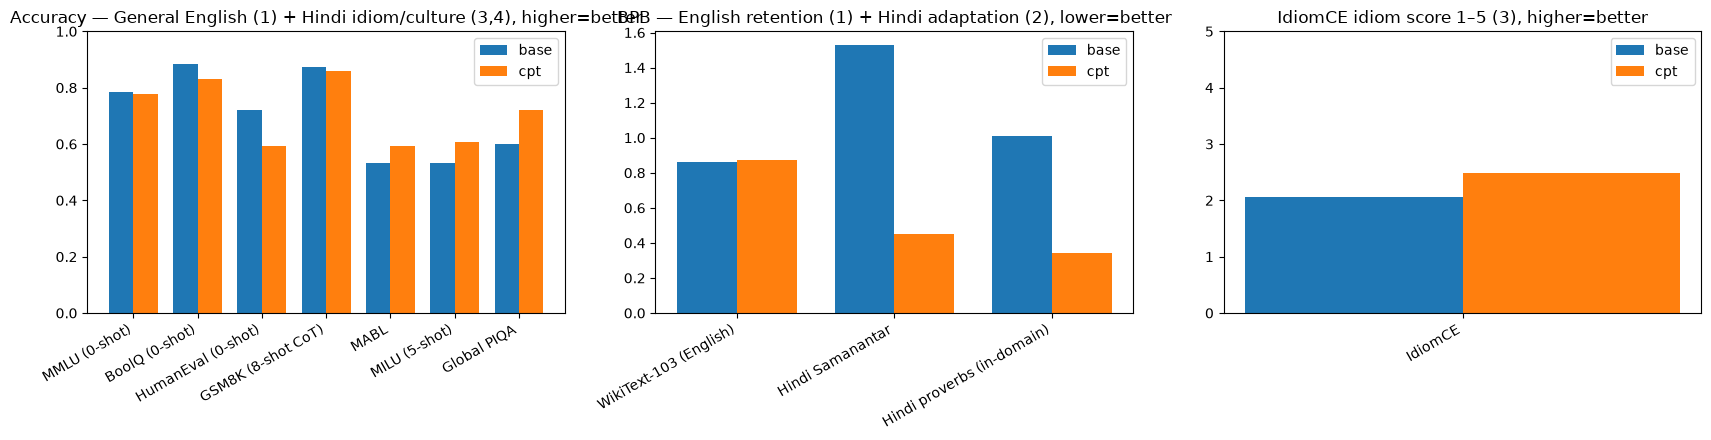

In [5]:
# ---- Plots grouped by category / metric type (avoids mixing scales) ------------
import matplotlib.pyplot as plt
import numpy as np

def gbar(df, title, ax, ylim=None):
    df = df.dropna(subset=['base', 'cpt'], how='all')
    if df.empty:
        ax.set_title(title + ' (no data)'); ax.axis('off'); return
    x = np.arange(len(df)); w = 0.38
    ax.bar(x - w/2, pd.to_numeric(df['base'], errors='coerce'), w, label='base')
    ax.bar(x + w/2, pd.to_numeric(df['cpt'], errors='coerce'), w, label='cpt')
    ax.set_xticks(x); ax.set_xticklabels(df['benchmark'], rotation=30, ha='right')
    ax.set_title(title); ax.legend()
    if ylim: ax.set_ylim(*ylim)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
# Accuracy-style (0-1): General English caps (cat 1) + Hindi idiom/culture (cat 3,4); exclude IdiomCE (1-5).
accbars = acc[(acc.better == 'higher') & (acc.metric != 'idiom_score(1-5)')].copy()
accbars = accbars.sort_values('category')
gbar(accbars, 'Accuracy — General English (1) + Hindi idiom/culture (3,4), higher=better', axes[0], (0, 1))
# BPB (lower=better): English retention (cat 1) + Hindi adaptation (cat 2)
gbar(lm[lm.metric == 'BPB'].sort_values('category'), 'BPB — English retention (1) + Hindi adaptation (2), lower=better', axes[1])
# IdiomCE 1-5 (cat 3)
gbar(acc[acc.metric == 'idiom_score(1-5)'], 'IdiomCE idiom score 1–5 (3), higher=better', axes[2], (0, 5))
plt.tight_layout(); plt.show()

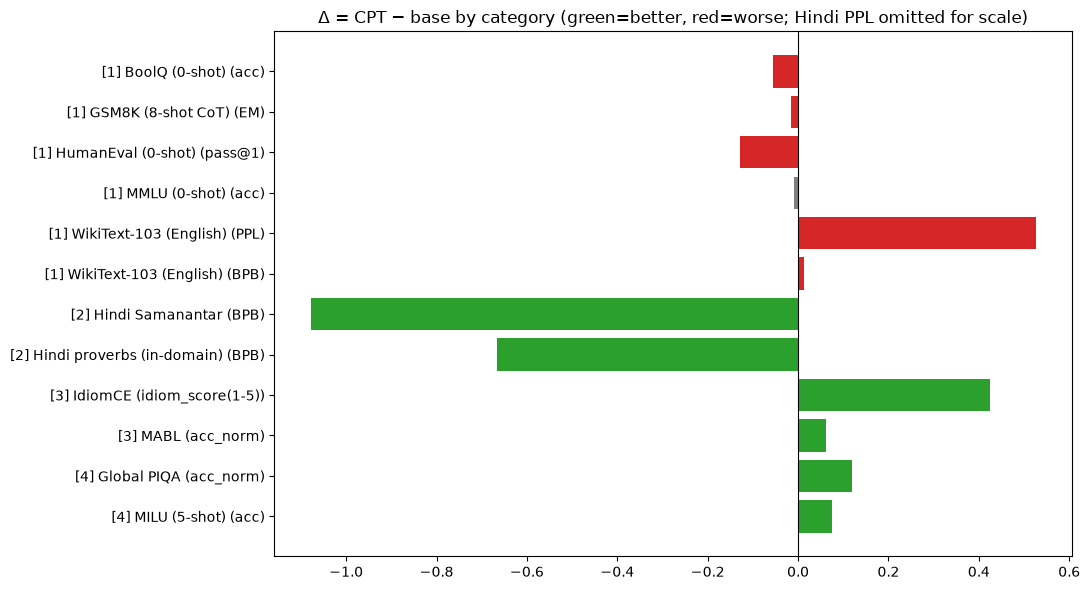

In [6]:
# ---- Delta view, ordered by category (Hindi PPL omitted for scale) -------------
d = allrows.dropna(subset=['delta']).copy()
d = d[~((d['category'] == 2) & (d['metric'] == 'PPL'))]  # Hindi PPL Δ≈-60 would dwarf all else
d = d.sort_values(['category', 'benchmark'])
if not d.empty:
    fig, ax = plt.subplots(figsize=(11, 6))
    colors = ['#2ca02c' if v == '✅ improved' else ('#d62728' if v == '⚠️ regressed' else '#7f7f7f')
              for v in d['verdict']]
    labels = [f"[{c}] {b} ({m})" for c, b, m in zip(d['category'], d['benchmark'], d['metric'])]
    ax.barh(labels, d['delta'], color=colors)
    ax.axvline(0, color='k', lw=0.8)
    ax.invert_yaxis()
    ax.set_title('Δ = CPT − base by category (green=better, red=worse; Hindi PPL omitted for scale)')
    plt.tight_layout(); plt.show()
else:
    print('No deltas available yet.')

## Reading the results

- **(1) General English (retention):** WikiText PPL/BPB, MMLU, and GSM8K stay ≈ flat; BoolQ dips
  mildly (−5.4); **HumanEval drops substantially (−12.8)** — coding is the skill most distant from
  the Hindi-only, code-free training distribution.
- **(2) Hindi language modeling (adaptation):** large PPL/BPB drop on both Hindi probes (strongest
  on the contaminated in-domain slice; still large on the independent Samanantar) — strong domain adaptation.
- **(3) Hindi idiom understanding:** MABL +6.1; IdiomCE idiom-score 2.06→2.48 (paired bootstrap
  95% CI [+0.31,+0.55], Wilcoxon p≈6e-11).
- **(4) Hindi general cultural competence:** Global PIQA +12.0; MILU +7.6.

**Caveats:** the proverb PPL is contaminated (training data); IdiomCE is judged by a single model
(gpt-5-4-mini), reference-less; HumanEval is greedy pass@1 with a re-indent fix. See
`docs/plans/hindi_cpt_eval_progress.md`.